<a href="https://colab.research.google.com/github/yainma/2026_tues_bigdatacomputing_class/blob/main/%EC%A4%91%EA%B0%84%EA%B3%A0%EC%82%AC_%ED%94%84%EB%A1%9C%EA%B7%B8%EB%9E%98%EB%B0%8D_%EA%B3%BC%EC%A0%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# [중간고사 실기 과제] 시계열 기상 데이터 통합 분석 파이프라인 구축
1. 과제 개요

  - 본 과제는 실무 데이터 분석 프로세스를 경험하기 위해 웹상의 기상 데이터를 수집하고, 이를 기계학습 모델링이 가능한 형태의 '깨끗한 데이터'로 가공하는 통합 분석 파이프라인을 개별 함수 단위로 구현하기.

2. 데이터 소스

  - URL: https://github.com/dongupak/DataML/raw/main/csv/weather.csv

  - 주요 컬럼: 지점, 일시, 평균기온, 최대풍속, 평균풍속

3. 핵심 요구 사항 (평가 기준)

  - 모듈화 설계:
    - 모든 기능은 독립적인 함수로 작성되어야 하고,
    - main() 함수에서 제어되어야 함.

  - 데이터 정규화 (Min-Max Scaling):
    - 특정 수치 데이터를 0과 1 사이로 변환하는 함수를 포함해야 함.

  - 시계열 핸들링:
    - 날짜 변환, 인덱스 설정 및 7일 이동 평균 추세선을 생성해야 함.

  - 데이터 재구조화:
    - pivot_table과 groupby를 활용하여 다차원적인 통계량을 산출해야 함.

  - 엑셀 내보내기 (To Excel):
    - 분석 결과인 전처리 데이터, 계절별 통계, 연도별 피벗 테이블을 하나의 엑셀 파일(weather_analysis_report.xlsx)의 별도 시트에 각각 저장해야 함.

  - 다음과 같은 데이터분석 그래프을 생성해야 함.
  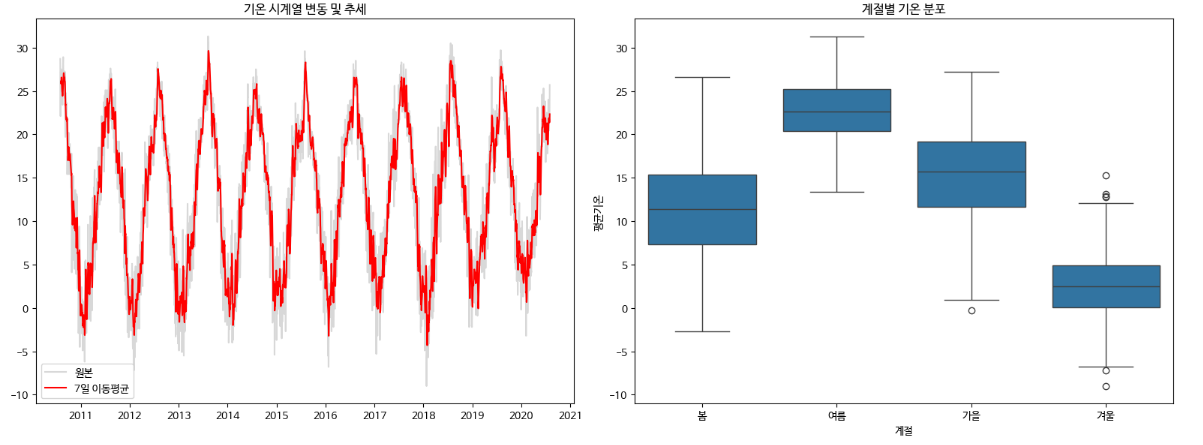

  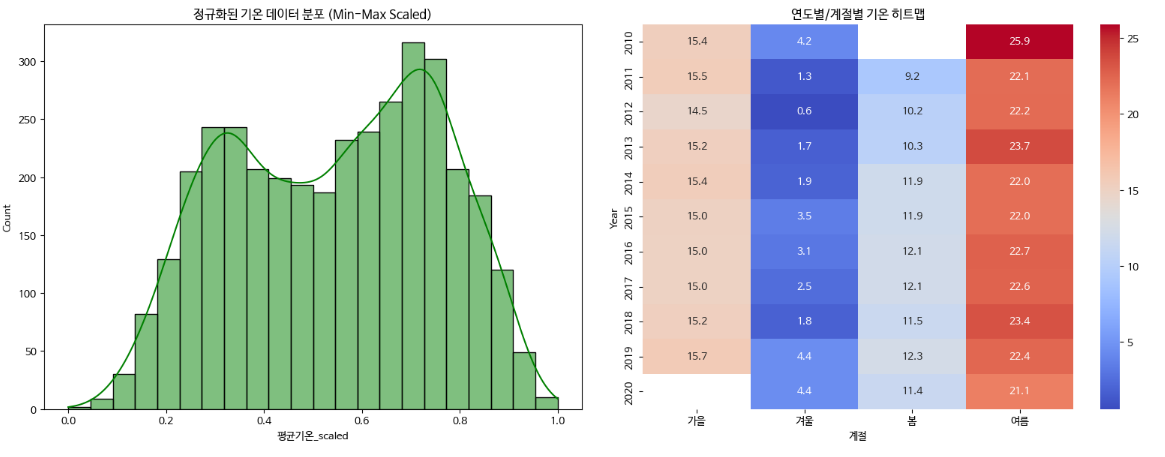



In [ ]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm -rf ~/.cache/matplotlib

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/n

데이터 로딩 중...
그래프 렌더링 중...


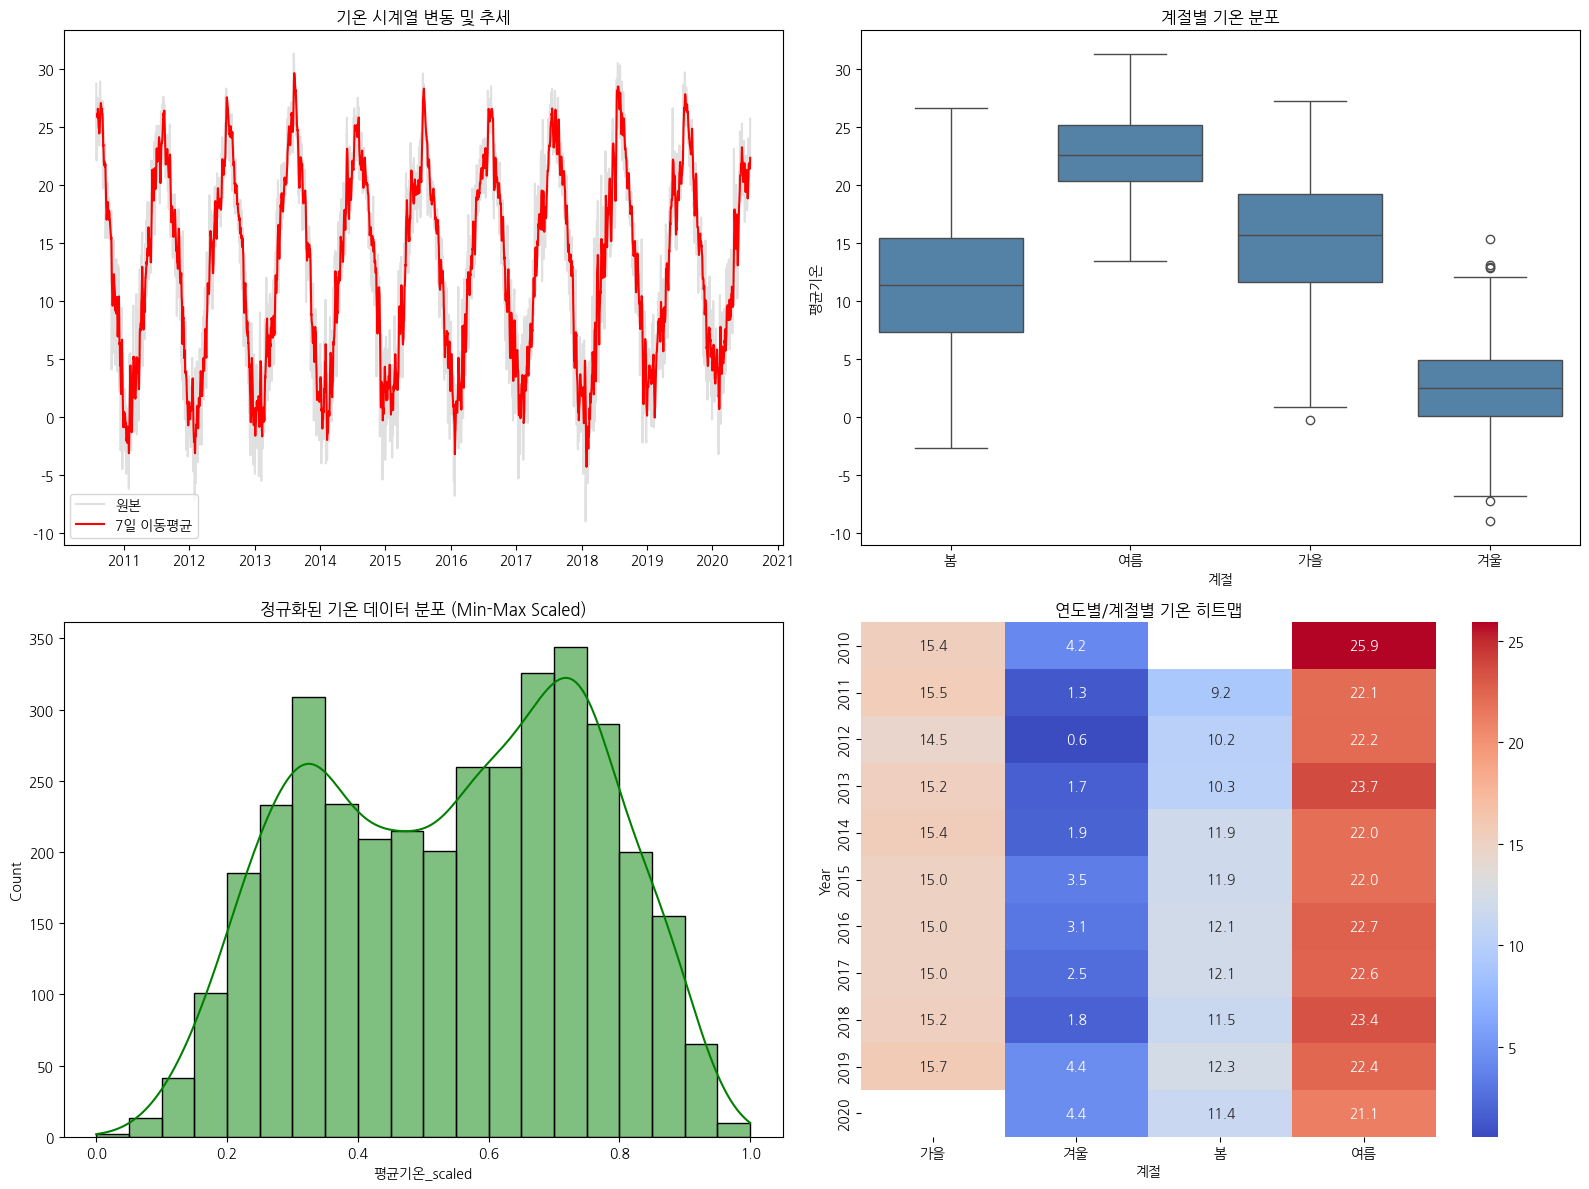

데이터 파이프라인 완료! 'weather_analysis_report.xlsx' 파일이 생성되었습니다.


In [ ]:
# 20250570 김채영
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import matplotlib.font_manager as fm
import warnings

warnings.filterwarnings('ignore')

# Colab용 한글 폰트 설정
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

def load_data(url):
    """1. 데이터 로드"""
    try:
        return pd.read_csv(url, encoding='cp949')
    except UnicodeDecodeError:
        return pd.read_csv(url, encoding='utf-8')

def preprocess_data(df):
    """2. 시계열 핸들링 및 전처리"""
    date_col = [c for c in df.columns if '일시' in c][0]
    temp_col = [c for c in df.columns if '평균기온' in c][0]

    df[date_col] = pd.to_datetime(df[date_col])
    df['Year'] = df[date_col].dt.year
    df['Month'] = df[date_col].dt.month

    def get_season(month):
        if 3 <= month <= 5: return '봄'
        elif 6 <= month <= 8: return '여름'
        elif 9 <= month <= 11: return '가을'
        else: return '겨울'

    df['계절'] = df['Month'].apply(get_season)

    df.set_index(date_col, inplace=True)
    df['7일_이동평균'] = df[temp_col].rolling(window=7).mean()

    return df, temp_col

def normalize_data(df, temp_col):
    """3. 데이터 정규화 (Min-Max Scaling)"""
    scaler = MinMaxScaler()
    temp_data = df[[temp_col]].ffill().bfill()
    df['평균기온_scaled'] = scaler.fit_transform(temp_data)
    return df

def restructure_data(df, temp_col):
    """4. 데이터 재구조화"""
    seasonal_stats = df.groupby('계절')[[temp_col]].describe()
    seasonal_stats.columns = ['_'.join(col).strip() for col in seasonal_stats.columns.values]

    pivot_df = df.pivot_table(index='Year', columns='계절', values=temp_col, aggfunc='mean')
    pivot_df = pivot_df[['가을', '겨울', '봄', '여름']]

    return seasonal_stats, pivot_df

def visualize_data(df, pivot_df, temp_col):
    """5. 데이터 시각화"""
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # 1) 기온 시계열 변동 및 추세
    axes[0, 0].plot(df.index, df[temp_col], color='lightgray', alpha=0.7, label='원본')
    axes[0, 0].plot(df.index, df['7일_이동평균'], color='red', label='7일 이동평균')
    axes[0, 0].set_title('기온 시계열 변동 및 추세')
    axes[0, 0].legend(loc='lower left')

    # 2) 계절별 기온 분포
    sns.boxplot(x='계절', y=temp_col, data=df, order=['봄', '여름', '가을', '겨울'],
                ax=axes[0, 1], color='steelblue')
    axes[0, 1].set_title('계절별 기온 분포')
    axes[0, 1].set_ylabel('평균기온')

    # 3) 정규화된 기온 데이터 분포
    sns.histplot(df['평균기온_scaled'], kde=True, color='green', bins=20, ax=axes[1, 0])
    axes[1, 0].set_title('정규화된 기온 데이터 분포 (Min-Max Scaled)')
    axes[1, 0].set_xlabel('평균기온_scaled')

    # 4) 연도별/계절별 기온 히트맵
    sns.heatmap(pivot_df, annot=True, fmt=".1f", cmap='coolwarm', ax=axes[1, 1])
    axes[1, 1].set_title('연도별/계절별 기온 히트맵')
    axes[1, 1].set_ylabel('Year')

    plt.tight_layout()
    plt.show()

def export_to_excel(df, seasonal_stats, pivot_df, filename):
    """6. 엑셀 내보내기"""
    df_reset = df.reset_index()
    date_col = [c for c in df_reset.columns if '일시' in c][0]
    df_reset[date_col] = df_reset[date_col].dt.strftime('%Y-%m-%d')

    with pd.ExcelWriter(filename, engine='openpyxl') as writer:
        df_reset.to_excel(writer, sheet_name='전처리_데이터', index=False)
        seasonal_stats.to_excel(writer, sheet_name='계절별_통계')
        pivot_df.to_excel(writer, sheet_name='연도별_피벗테이블')

def main():
    """메인 컨트롤 함수"""
    url = 'https://github.com/dongupak/DataML/raw/main/csv/weather.csv'
    print("데이터 로딩 중...")

    df = load_data(url)
    df, temp_col = preprocess_data(df)
    df = normalize_data(df, temp_col)
    seasonal_stats, pivot_df = restructure_data(df, temp_col)

    print("그래프 렌더링 중...")
    visualize_data(df, pivot_df, temp_col)

    export_to_excel(df, seasonal_stats, pivot_df, 'weather_analysis_report.xlsx')
    print("데이터 파이프라인 완료! 'weather_analysis_report.xlsx' 파일이 생성되었습니다.")

if __name__ == '__main__':
    main()